In [11]:
%load_ext autoreload
%autoreload 2
import sys
if "../" not in sys.path:
    sys.path.append("../")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.special import roots_laguerre
from scipy.integrate import quad
from math import factorial

import signature.tensor_algebra as ta
from signature.ode_integration import *

PALETTE = ["#5C7B55", "#C0714A", "#C9A84C", "#A8C5A0", "#8B5A6B", "#4A5568"]
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=PALETTE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
T = 0.05

In [13]:
N = 19
dim = 1
e = ta.AlgebraBasis(dim=dim, trunc=N)

#### Laplace transform Via MC

In [14]:
p_coef = -24
pol = lambda x: p_coef * (x**4 / 24)

In [15]:
rng = np.random.default_rng(seed=42)
n_sample = 10**6
W_T = rng.normal(size=n_sample) * np.sqrt(T)
sample = np.exp(pol(W_T))
sample.mean(), sample.std() / np.sqrt(n_sample)

(0.992773320790196, 2.2053026474954028e-05)

#### Via quadratures

In [16]:
N_points = 150

z_arr, w_arr = roots_laguerre(n=N_points)

def f(x):
    return np.exp(pol(np.sqrt(T) * x[None, :]) - 0.5 * x[None, :]**2) / np.sqrt(2 * np.pi) * 2

cf_quad = f(z_arr) @ (w_arr * np.exp(z_arr))
cf_quad[-1]

0.9928039079789808

In [17]:
np.log(cf_quad[-1])

-0.007222108778998601

#### Via inf-dimensional Riccati

In [18]:
shuffle_table = ta.get_shuffle_table(table_trunc=N, dim=dim)
args = {"shuffle_table": shuffle_table}

@jax.jit
def ode_fun(psi: ta.TensorSequence, args: dict) -> ta.TensorSequence:
    return psi.proj(11) * 0.5 + ta.shuffle_pow(psi.proj(1), 2, args["shuffle_table"]) * 0.5

In [19]:
p_trunc = N
t_grid = np.linspace(0, T, 1000)
p= ta.from_word(1111, trunc=p_trunc, dim=1) * (p_coef)

step_fun = step_fun_pece # step_fun_euler

psi = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=t_grid, init=p, args=args)
psi_T = psi.subsequence([-1,])
print(np.exp(psi_T[0]), np.abs(np.exp(psi_T[0]) - cf_quad[-1]))

0.9928039072775828 7.013979397285652e-10


## MC for all $x$

In [20]:
r = 2
N_x_grid = 100
x_grid = np.linspace(-r, r, N_x_grid)


p_coef = -24
pol = lambda x: p_coef * (x ** 4 / 24)
rng = np.random.default_rng(seed=42)
n_sample = 10 ** 6
W_T = rng.normal(size=n_sample) * np.sqrt(T)
sample = np.exp(pol(x_grid[None, :] + W_T[:, None]))
cf_mc = sample.mean(axis=0)

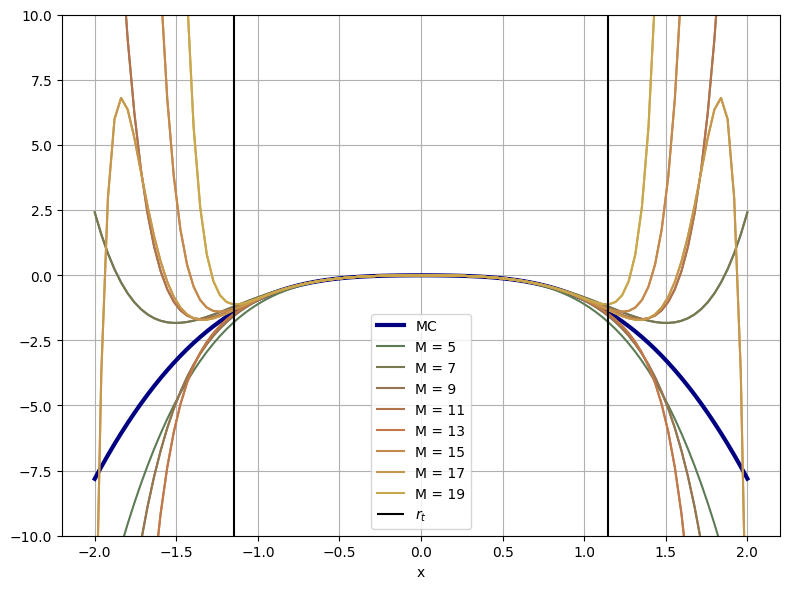

In [21]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import factorial
from matplotlib.colors import LinearSegmentedColormap

# --- Your custom palette ---
hex_colors = ["#5C7B55", "#C0714A", "#C9A84C"]
custom_cmap = LinearSegmentedColormap.from_list("custom", hex_colors)

norm = matplotlib.colors.Normalize(vmin=0, vmax=1)


factorials = np.array([factorial(i) for i in range(N + 1)])
x_arr = (x_grid[None, :] ** np.arange(N + 1)[:, None]) / factorials[:, None]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_grid, np.log(cf_mc), "-", color="navy", label="MC", lw=3)

truncations = np.arange(5, N + 1)
L = len(truncations)

# How often to show a legend label (tune this to taste)
label_every = max(1, L // 6)

for i, trunc in enumerate(truncations):
    color = custom_cmap(norm(i / max(L - 1, 1)))
    # Only label every Nth line; others get _nolegend_
    label = f"M = {trunc}" if i % label_every == 0 or i == L - 1 else "_nolegend_"
    ax.plot(x_grid, np.real(psi_T.array[:trunc + 1] @ x_arr[:trunc + 1]),
            label=label, color=color)

ax.set_xlabel("x")

y_lim_1, y_lim_2 = -10, 10
R = 1.147147147147147
ax.vlines(R,  y_lim_1, y_lim_2, "k", label="$r_t$")
ax.vlines(-R, y_lim_1, y_lim_2, "k")
ax.set_ylim([y_lim_1, y_lim_2])

ax.legend()
fig.tight_layout()
plt.savefig("images/riccati_zeros/psi_series.pdf", format="pdf", transparent=True)

# Comparing different methods: Riccati, Centered Riccati, Monte Carlo

In [22]:
T = 0.05          # time horizon
N = 19
dim = 1
e = ta.AlgebraBasis(dim=dim, trunc=N)

r = 2
N_x_grid = 100
x_grid = np.linspace(-r, r, N_x_grid)

#### Via MC

In [23]:
p_coef = -24
pol = lambda x: p_coef * (x**4 / 24)

In [24]:
rng = np.random.default_rng(seed=42)
n_sample = 10**6
W_T = rng.normal(size=n_sample) * np.sqrt(T)
sample = np.exp(pol(x_grid[None, :] + W_T[:, None]))
cf_mc = sample.mean(axis=0)

#### Via inf-dimensional Riccati

In [25]:
shuffle_table = ta.get_shuffle_table(table_trunc=N, dim=dim)
args = {"shuffle_table": shuffle_table}

In [26]:
@jax.jit
def ode_fun(psi: ta.TensorSequence, args: dict) -> ta.TensorSequence:
    return psi.proj(11) * 0.5 + ta.shuffle_pow(psi.proj(1), 2, args["shuffle_table"]) * 0.5

In [27]:
p_trunc = N
n = 1000
t_grid = np.linspace(0, T, n)
p = ta.from_word(1111, trunc=p_trunc, dim=1) * (p_coef)

In [28]:
# fig, ax = plt.subplots(figsize=(12, 6))

step_fun = step_fun_pece # step_fun_euler

psi = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=t_grid, init=p, args=args)
psi_T = psi.subsequence([-1,])
print(np.exp(psi_T[0]))
# ta.plot_coefficients(psi_T, nonzero=True, ax=ax)

0.9928039072775828


#### Recentered inf-dimensional Riccati

In [29]:
shuffle_table = ta.get_shuffle_table(table_trunc=N, dim=dim)
args = {"shuffle_table": shuffle_table}

In [30]:
p_trunc = N
n = 1000
t_grid = np.linspace(0, T, n)
p = ta.from_word(1111, trunc=p_trunc, dim=1) * (p_coef)

In [31]:
dim_sig = ta.number_of_words_up_to_trunc(dim=dim, trunc=N)
proj_mat = np.zeros((dim_sig, dim_sig))

for i in range(dim_sig):
    v = ta.index_to_word(i, dim)
    proj_mat[i] = p.proj(v).array

In [32]:
factorials = np.array([factorial(i) for i in range(N + 1)])
x_arr = (x_grid[None, :] ** np.arange(N + 1)[:, None]) / factorials[:, None]
p_left_proj_x_arr = ta.left_proj_on_seq(ts=p, proj_on=x_arr)

In [33]:
@jax.jit
def ode_fun(psi: ta.TensorSequence, args: dict) -> ta.TensorSequence:
    return psi.proj(11) * 0.5 + ta.shuffle_pow(psi.proj(1), 2, args["shuffle_table"]) * 0.5

In [34]:
psi_centered_arr = np.zeros_like(x_grid)

for i, p_x in enumerate(p_left_proj_x_arr.array.T):
    p_left_proj_x = ta.from_array(p_x, N, dim)
    step_fun = step_fun_pece # step_fun_euler

    psi_centered = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=t_grid, init=p_left_proj_x, args=args)
    psi_T_centered = psi_centered.subsequence([-1,])
    psi_centered_arr[i] = psi_T_centered[0]

#### Plotting all the results

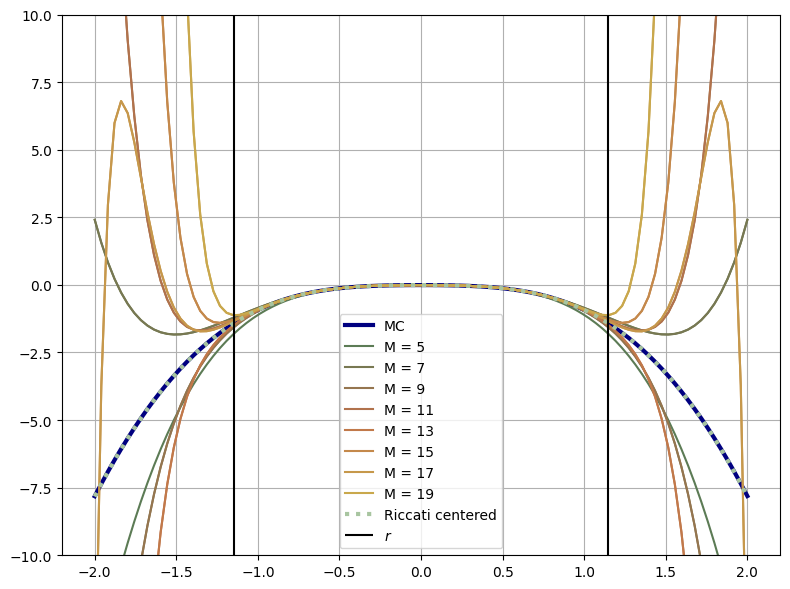

In [35]:
norm = matplotlib.colors.Normalize(vmin=0, vmax=1)
hex_colors = ["#5C7B55", "#C0714A", "#C9A84C"]
cmap = LinearSegmentedColormap.from_list("custom", hex_colors)

factorials = np.array([factorial(i) for i in range(N + 1)])
x_arr = (x_grid[None, :] ** np.arange(N + 1)[:, None]) / factorials[:, None]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_grid, np.log(cf_mc), "-", color="navy", label="MC", lw=3)

# ran = np.arange(N-6, N+1, 2)
# L = len(ran)
# for i, trunc in enumerate(ran):
#     ax.plot(x_grid, np.real(psi_T.array[:trunc + 1] @ x_arr[:trunc + 1]), label=f"M = {trunc}", color=cmap(norm(i / L)))
# ax.set_xlabel("x")


truncations = np.arange(5, N + 1)
L = len(truncations)

# How often to show a legend label (tune this to taste)
label_every = max(1, L // 6)

for i, trunc in enumerate(truncations):
    color = custom_cmap(norm(i / max(L - 1, 1)))
    # Only label every Nth line; others get _nolegend_
    label = f"M = {trunc}" if i % label_every == 0 or i == L - 1 else "_nolegend_"
    ax.plot(x_grid, np.real(psi_T.array[:trunc + 1] @ x_arr[:trunc + 1]),
            label=label, color=color)



ax.plot(x_grid, psi_centered_arr, ls=":", label="Riccati centered", color="#A8C5A0", lw=3)

y_lim_1, y_lim_2 = -10, 10

ax.vlines(R, y_lim_1, y_lim_2, "k", label="$r$")
ax.vlines(-R, y_lim_1, y_lim_2, "k")

ax.set_ylim([y_lim_1, y_lim_2])
ax.legend()

fig.tight_layout()
plt.savefig("images/riccati_zeros/psi_series_recentered.pdf", format="pdf", transparent=True)

## Optimal control problem

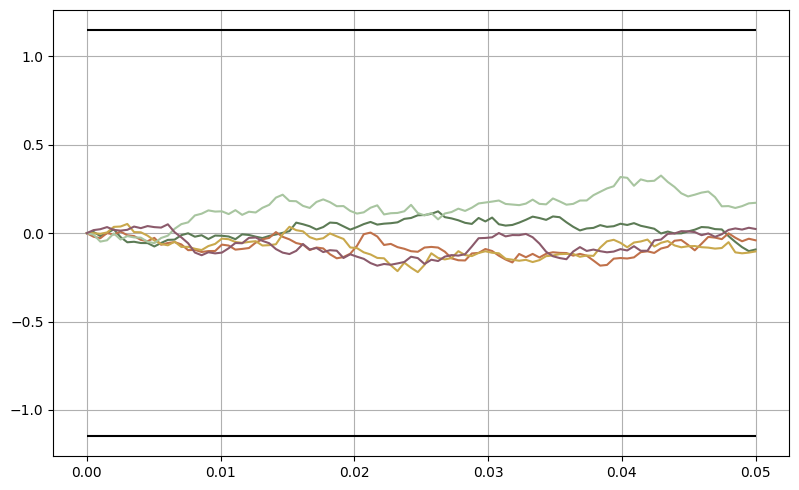

In [36]:
# Simulating Brownian trajectories
from simulation.diffusion import Diffusion

n_time_grid_control = 100
time_grid_control = np.linspace(0, T, n_time_grid_control)
rng = np.random.default_rng(seed=42)

size = 5
W_batch = Diffusion(t_grid=time_grid_control, size=size, rng=rng).W_traj[:, 0, :] # a batch of shape (size, n_time_grid_control)

for i in range(size):
    plt.plot(time_grid_control, W_batch[i])

plt.hlines(y=R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")
plt.hlines(y=-R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")

In [37]:
# Solving the Riccati (without recentering)

p = ta.from_word(1111, trunc=p_trunc, dim=1) * (p_coef) * 100 - ta.from_word(11, trunc=p_trunc, dim=1) * 1000

psi = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=time_grid_control, init=p, args=args)
psi_T = psi.subsequence([-1,])
print(psi_T[0])

psi_proj_W = psi.proj(1)

-1.9684988480180414


In [38]:
def get_1d_sig(x, N):
    factorials = np.array([factorial(i) for i in range(N + 1)])
    return (x[None, :] ** np.arange(N + 1)[:, None]) / factorials[:, None]

In [39]:
# Computing the control and the controlled variable

X_alpha_batch = np.zeros_like(W_batch)
alpha_batch = np.zeros_like(W_batch)
psi_batch = np.zeros_like(W_batch)
norm_tracker_batch = np.zeros_like(W_batch)

dt_control = np.diff(time_grid_control)
dW_batch = np.diff(W_batch, axis=1)

for i in range(1, n_time_grid_control):
    sig_t = get_1d_sig(X_alpha_batch[:, i-1], N) # array of shape (N_sig, size)
    alpha = psi_proj_W.array[:, -i] @ sig_t # (-i) as we changed the time in Riccati
    X_alpha_batch[:, i] = X_alpha_batch[:, i - 1] + alpha * dt_control[i - 1] + dW_batch[:, i-1]
    alpha_batch[:, i - 1] = alpha
    psi_batch[:, i - 1] = psi.array[:, -i] @ sig_t
    norm_tracker_batch[:, i - 1] = np.abs(psi.array[1:, -i]) @ np.abs(sig_t[1:]) / np.log(2)

Text(0.5, 1.0, 'Norm tracker $\\|\\overline{\\psi_t}\\|_{\\mathbb{X}_t^{\\alpha}} / \\log 2$')

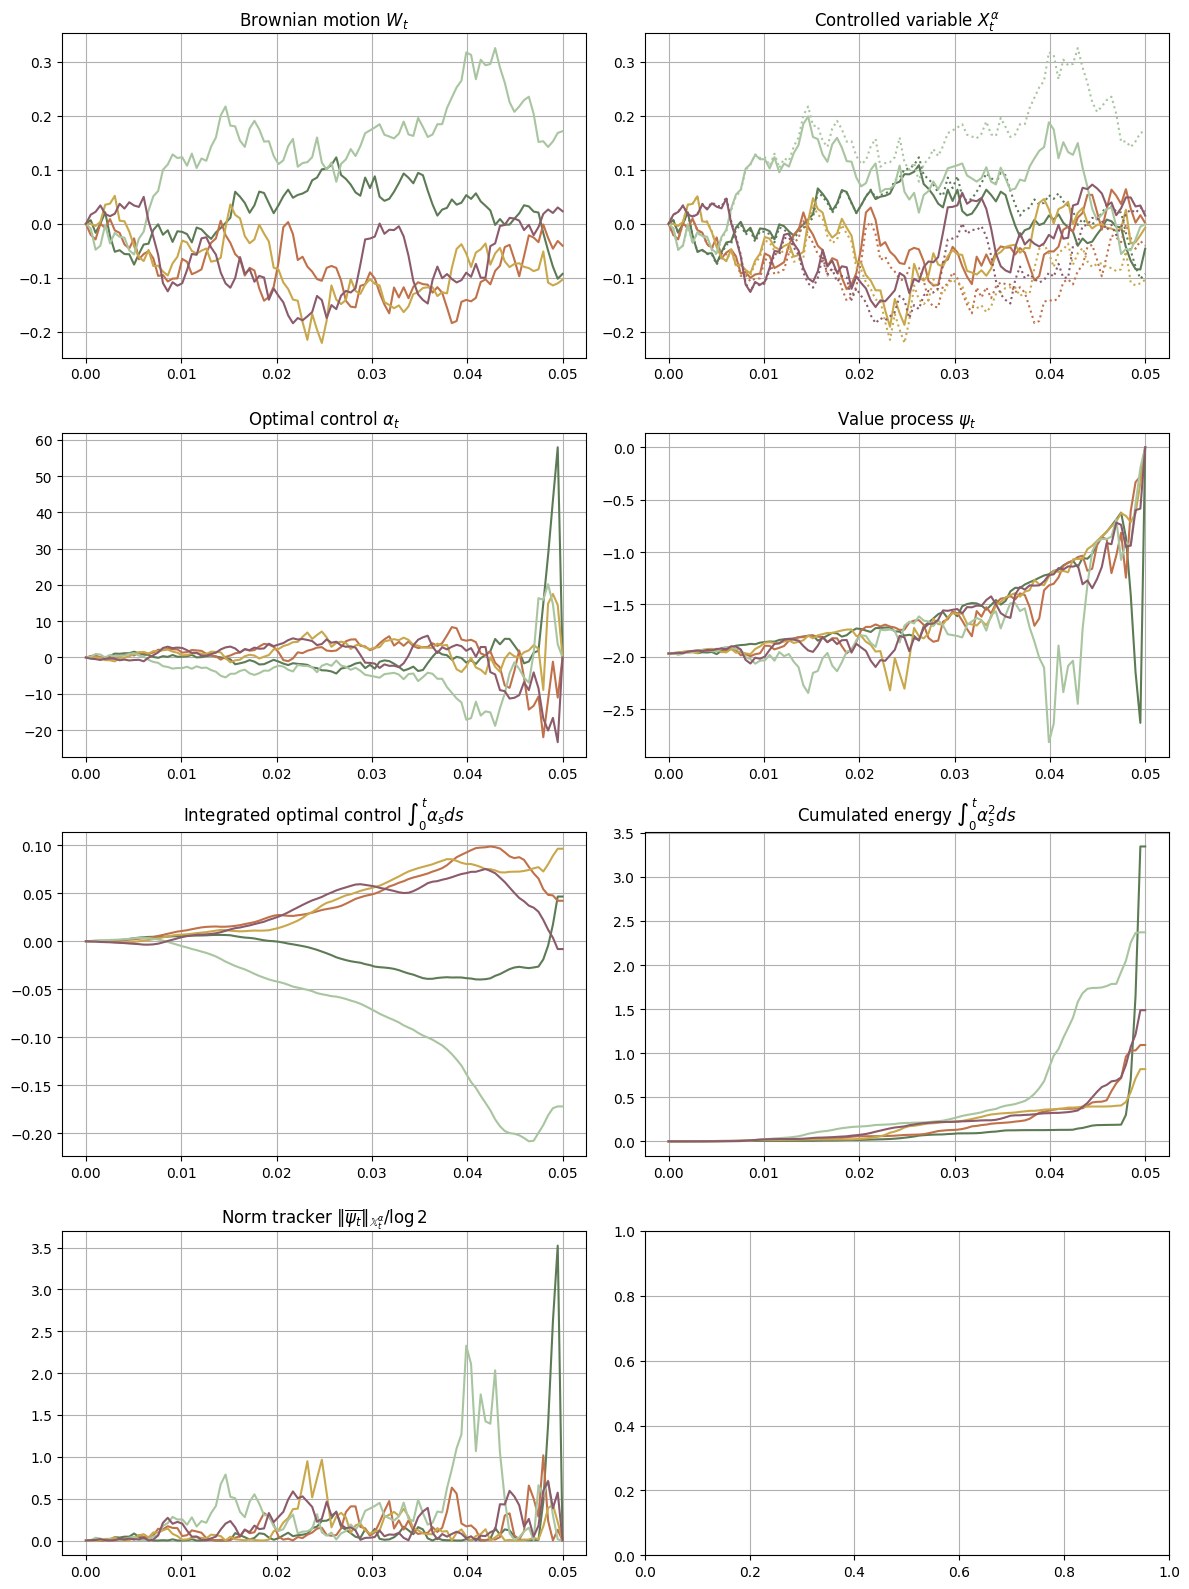

In [40]:
fig, ax = plt.subplots(4, 2, figsize=(12, 16))

for i in range(size):
    ax[0, 0].plot(time_grid_control, W_batch[i])
    ax[0, 1].plot(time_grid_control, X_alpha_batch[i], color=PALETTE[i])
    ax[0, 1].plot(time_grid_control, W_batch[i], ":", color=PALETTE[i])
    ax[1, 0].plot(time_grid_control, alpha_batch[i])
    ax[1, 1].plot(time_grid_control, psi_batch[i])
    ax[2, 0].plot(time_grid_control, np.cumsum(alpha_batch * dt_control[0], axis=1)[i])
    ax[2, 1].plot(time_grid_control, np.cumsum(alpha_batch**2 * dt_control[0], axis=1)[i])
    ax[3, 0].plot(time_grid_control, norm_tracker_batch[i],)


ax[0, 0].set_title(r"Brownian motion $W_t$")
ax[0, 1].set_title(r"Controlled variable $X^\alpha_t$")
ax[1, 0].set_title(r"Optimal control $\alpha_t$")
ax[1, 1].set_title(r"Value process $\psi_t$")
ax[2, 0].set_title(r"Integrated optimal control $\int_0^t\alpha_sds$")
ax[2, 1].set_title(r"Cumulated energy $\int_0^t\alpha^2_sds$")
ax[3, 0].set_title(r"Norm tracker $\|\overline{\psi_t}\|_{\mathbb{X}_t^{\alpha}} / \log 2$")

# ax[0, 0].hlines(y=R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")
# ax[0, 0].hlines(y=-R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")

# ax[0, 1].hlines(y=R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")
# ax[0, 1].hlines(y=-R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")

## Optimal control problem for signatures

In [41]:
T = 0.1
trunc = p_trunc = 10
dim = 2

shuffle_table = ta.get_shuffle_table(table_trunc=trunc, dim=dim)
args = {"shuffle_table": shuffle_table}
step_fun = step_fun_pece # step_fun_euler

@jax.jit
def ode_fun(psi: ta.TensorSequence, args: dict) -> ta.TensorSequence:
    return psi.proj(1) + psi.proj(22) * 0.5 + ta.shuffle_pow(psi.proj(2), 2, args["shuffle_table"]) * 0.5


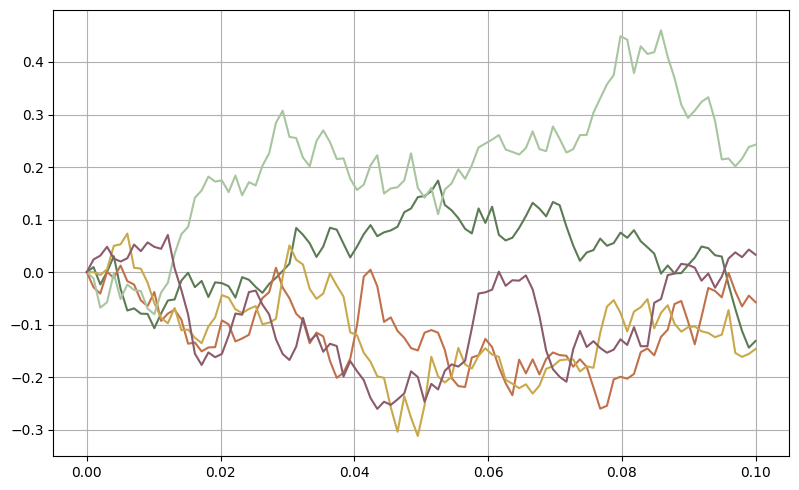

In [42]:
# Simulating Brownian trajectories
from simulation.diffusion import Diffusion

n_time_grid_control = 100
time_grid_control = np.linspace(0, T, n_time_grid_control)
rng = np.random.default_rng(seed=42)

size = 5
W_batch = Diffusion(t_grid=time_grid_control, size=size, rng=rng).W_traj[:, 0, :] # a batch of shape (size, n_time_grid_control)

for i in range(size):
    plt.plot(time_grid_control, W_batch[i])

In [43]:
# Solving the Riccati (without recentering)

p = ta.from_word(2222, trunc=p_trunc, dim=dim) * (p_coef) * 100 - ta.from_word(22, trunc=p_trunc, dim=dim) * 100  - ta.from_word(221, trunc=p_trunc, dim=dim) * 1000
print("p = ", p)

psi = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=time_grid_control, init=p, args=args)
psi_T = psi.subsequence([-1,])
print(psi_T[0])

psi_proj_W = psi.proj(2)

p =  -100.0*22 + -1000.0*221 + -2400.0*2222
-1.9631819145142153


In [44]:
from signature.path_signature import __compute_inc_sig_constant_lam

In [45]:
# Initializing empty signatures
n_sig = ta.number_of_words_up_to_trunc(dim=dim, trunc=trunc)
X_sig = np.zeros((n_sig, size))
X_sig[0] = 1
X_sig = ta.from_array(X_sig, trunc=trunc, dim=dim)

In [46]:
# Computing the control and the controlled variable

X_alpha_batch = np.zeros_like(W_batch)
alpha_batch = np.zeros_like(W_batch)
psi_batch = np.zeros_like(W_batch)
norm_tracker_batch = np.zeros_like(W_batch)

dt_control = np.diff(time_grid_control)
dW_batch = np.diff(W_batch, axis=1)

for i in range(1, n_time_grid_control):
    alpha = psi_proj_W.array[:, -i] @ X_sig.array  # (-i) as we changed the time in Riccati
    dX_state = alpha * dt_control[i - 1] + dW_batch[:, i - 1]
    X_alpha_batch[:, i] = X_alpha_batch[:, i - 1] + dX_state
    alpha_batch[:, i - 1] = alpha
    psi_batch[:, i - 1] = psi.array[:, -i] @ X_sig.array
    norm_tracker_batch[:, i - 1] = (psi.subsequence((-i,)).seminorm(X_sig)
                                    - np.abs(psi.array[0, -i])) / np.log(2)

    # Time-augmented increment of the path (t, X^alpha): column 0 = time (letter 1),
    # column 1 = controlled state (letter 2). Shape (size, dim), as required by the signature routine.
    dX_path = jnp.stack([dt_control[i - 1] * jnp.ones(size), dX_state], axis=1)
    X_sig_inc = __compute_inc_sig_constant_lam(dX=dX_path, dt=dt_control[i - 1] * jnp.ones(size),
                                               lam=jnp.zeros(dim), dim=dim, trunc=trunc)
    # Chen's identity: signature up to t_i = signature up to t_{i-1} (X) increment signature
    X_sig = ta.tensor_prod(X_sig, X_sig_inc)

Text(0.5, 1.0, 'Norm tracker $\\|\\overline{\\psi_t}\\|_{\\mathbb{X}_t^{\\alpha}} / \\log 2$')

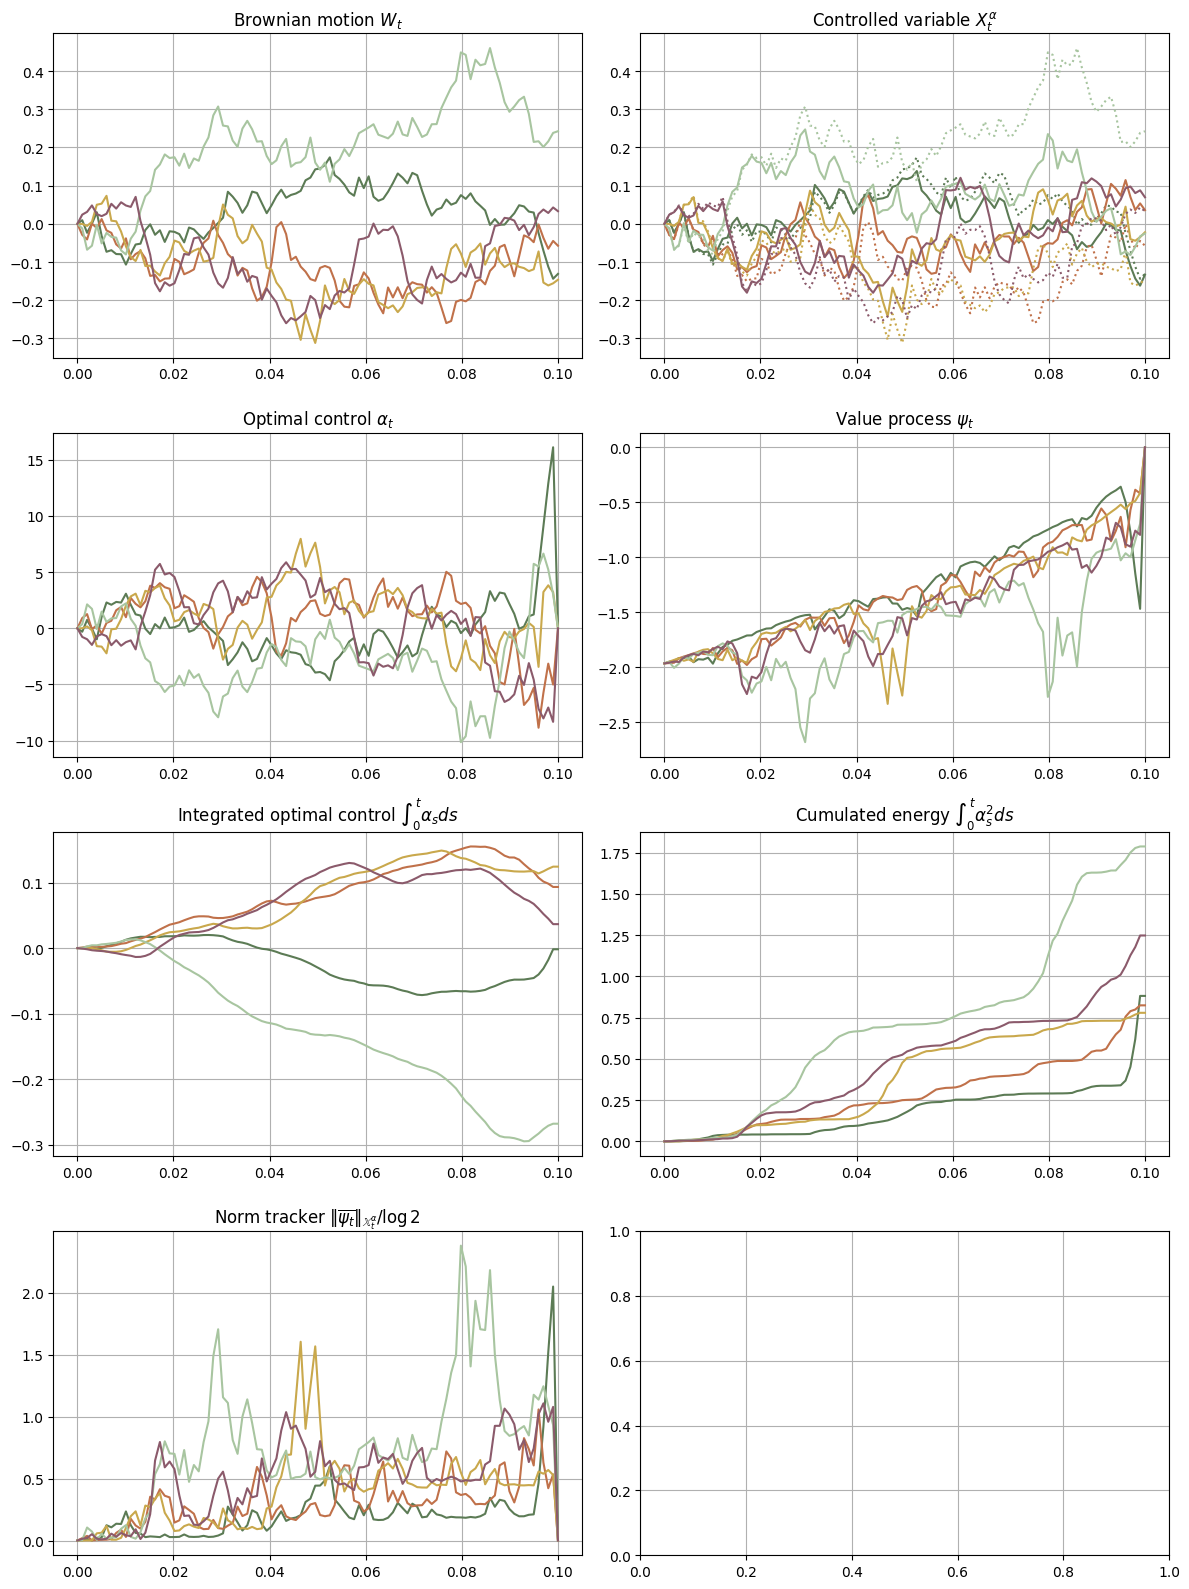

In [47]:
fig, ax = plt.subplots(4, 2, figsize=(12, 16))

for i in range(size):
    ax[0, 0].plot(time_grid_control, W_batch[i])
    ax[0, 1].plot(time_grid_control, X_alpha_batch[i], color=PALETTE[i])
    ax[0, 1].plot(time_grid_control, W_batch[i], ":", color=PALETTE[i])
    ax[1, 0].plot(time_grid_control, alpha_batch[i])
    ax[1, 1].plot(time_grid_control, psi_batch[i])
    ax[2, 0].plot(time_grid_control, np.cumsum(alpha_batch * dt_control[0], axis=1)[i])
    ax[2, 1].plot(time_grid_control, np.cumsum(alpha_batch**2 * dt_control[0], axis=1)[i])
    ax[3, 0].plot(time_grid_control, norm_tracker_batch[i],)


ax[0, 0].set_title(r"Brownian motion $W_t$")
ax[0, 1].set_title(r"Controlled variable $X^\alpha_t$")
ax[1, 0].set_title(r"Optimal control $\alpha_t$")
ax[1, 1].set_title(r"Value process $\psi_t$")
ax[2, 0].set_title(r"Integrated optimal control $\int_0^t\alpha_sds$")
ax[2, 1].set_title(r"Cumulated energy $\int_0^t\alpha^2_sds$")
ax[3, 0].set_title(r"Norm tracker $\|\overline{\psi_t}\|_{\mathbb{X}_t^{\alpha}} / \log 2$")

# ax[0, 0].hlines(y=R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")
# ax[0, 0].hlines(y=-R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")

# ax[0, 1].hlines(y=R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")
# ax[0, 1].hlines(y=-R, xmin=time_grid_control[0], xmax=time_grid_control[-1], color="k")

## Double-well + Lévy-area + signature-matching control

Controlled noise $dX_t=\alpha_t\,dt+dW_t$, augmented to $\widehat{\mathbb X}_t=\mathrm{sig}\big((s,X_s)_{s\le t}\big)$ (letter $1$ = time, letter $2$ = state). The terminal coefficient $p$ is built as a **sum of three cost components**:

1. **Double-well** (running) — $w_1\int_0^T(X_t^2-\mu^2)^2\,dt$: keep $|X|$ near $\mu$ (minima at $X=\pm\mu$).
2. **Lévy area** (running) — $w_2\int_0^T A_t^2\,dt$ with $A_t=\tfrac12(\widehat{\mathbb X}^{12}_t-\widehat{\mathbb X}^{21}_t)=\tfrac12 tX_t-\int_0^t X_s\,ds$: drive $A_t\to0$ (balanced time in the two wells).
3. **Signature matching** (terminal) — $w_{\rm term}\,\lVert\mathrm{Sig}(X)_T-\mathrm{Sig}^\star\rVert^2$: match the controlled signature at $T$ to the signature $\mathrm{Sig}^\star$ of a target path. Expanding the square gives the quadratic $(\widehat{\mathbb X}^v_T)^2$ and the cross term $-2\,\mathrm{Sig}^{\star v}\widehat{\mathbb X}^v_T$; we keep only the **non-constant** terms, i.e. **state-involving** words $v$ (the pure-time words and $\lVert\mathrm{Sig}^\star\rVert^2$ are deterministic constants and drop out of the control).


The two running costs append the time letter (to integrate over $[0,T]$); the terminal sig-matching cost does not. Thus $p=p_{\rm well}+p_{\rm area}+p_{\rm sig}$, and the optimal feedback is $\alpha_t=\langle\psi_t|_2,\widehat{\mathbb X}_t\rangle$. Weights must be kept moderate so the norm tracker stays $<1$ (radius of convergence).

In [48]:
# ===== Double-well + Lévy-area + signature-matching control =====
from signature.path_signature import __compute_inc_sig_constant_lam

dim   = 2
trunc = 12
shuffle_table = ta.get_shuffle_table(table_trunc=trunc, dim=dim)
args  = {"shuffle_table": shuffle_table}    # "source" (a (n_sig, n_dw) trajectory) is added below
step_fun = step_fun_pece

# Generator of the controlled augmented signature (1 = time, 2 = state, sigma = 1):
#   R psi = psi|_1 + 1/2 psi|_22 + 1/2 (psi|_2)^{shuffle 2}
@jax.jit
def ode_fun(psi: ta.TensorSequence, args: dict) -> ta.TensorSequence:
    # args["i"] is the reversed-time integration step injected by the solver, so args["source"]
    # (shape (n_sig, n_dw)) is sliced at column i = the source at calendar time T - t_grid[i].
    source_t = ta.TensorSequence(array=args["source"].array[:, args["i"]], trunc=psi.trunc, dim=psi.dim)
    return psi.proj(1) + psi.proj(22) * 0.5 + ta.shuffle_pow(psi.proj(2), 2, args["shuffle_table"]) * 0.5 + source_t

# ----- problem parameters (keep weights moderate so the norm tracker stays < 1) -----
T_dw   = 0.1        # horizon (short: control valid only up to the radius of convergence)
mu     = 0.5        # double-well minima at X = +- mu
w1     = 20.0        # weight: (X^2 - mu^2)^2          (double well, running)
w2     = 0.1 * 0        # weight: A^2                     (Levy area,   running)
w_term = 2.0 * 0        # weight: ||Sig(X)_T - Sig*||^2   (sig matching, terminal)
M_sig  = 2          # match the signature up to order M_sig
n_dw   = 150
size   = 5
t_grid = np.linspace(0, T_dw, n_dw)

e_time  = ta.from_word(1, trunc, dim)
e_state = ta.from_word(2, trunc, dim)
unit    = ta.unit(trunc, dim)

# (1) double-well, running:  -w1 * int_0^T (X^2 - mu^2)^2 dt   (append time letter to integrate)
Y1     = ta.shuffle_pow(e_state, 2, shuffle_table) - unit * (mu ** 2)         # X^2 - mu^2
# Y1 = ta.shuffle_pow(e_state - unit * mu, 2, shuffle_table) # a simpler target
q_well = ta.shuffle_pow(Y1, 2, shuffle_table) * (-w1) # source term
p_well = ta.tensor_prod(q_well, e_time)

# (2) Levy area, running:  -w2 * int_0^T A_t^2 dt,  A_t = 1/2 (X^12 - X^21)
ell_A  = (ta.from_word(12, trunc, dim) - ta.from_word(21, trunc, dim)) * 0.5
q_area = ta.shuffle_pow(ell_A, 2, shuffle_table) * (-w2)
p_area = ta.tensor_prod(q_area, e_time) 

# (3) signature matching, terminal:  -w_term * ||Sig(X)_T - Sig*||^2
#   = -w_term * sum_v [ (X^v)^2 - 2 Sig*^v X^v ]   over NON-CONSTANT (state-involving) words v.
#   Target path: a smooth quarter-sine rise from 0 to mu; its terminal signature is Sig*.
Y_target = mu * np.sin(2 * np.pi * t_grid / (T_dw))
Sig_star = ta.path_to_signature(jnp.asarray(np.column_stack([t_grid, Y_target])),
                                trunc, only_terminal_sig=True)
p_sig = ta.zero(trunc, dim)
for idx in range(1, ta.number_of_words_up_to_trunc(dim=dim, trunc=M_sig)):
    word = int(ta.index_to_word(idx, dim))
    if "2" in str(word):                       # keep only state-involving (non-constant) words
        v = ta.from_word(word, trunc, dim)
        p_sig = p_sig + ta.shuffle_pow(v, 2, shuffle_table) - v * (2.0 * float(Sig_star.array[idx]))
p_sig = p_sig * (-w_term)

# ----- the three components add up to p -----
q = q_well + q_area
r = p_sig

# r = p_well + p_area + p_sig # terminal cond
# q = ta.zero(trunc=trunc, dim=dim)

# Source as a (n_sig, n_dw) trajectory: column i holds the source at the reversed-time
# integration step i, i.e. at calendar time T - t_grid[i].  q is time-independent here so the
# columns coincide; for a time-dependent running cost q(t) set source[:, i] = q(T_dw - t_grid[i])
# (e.g. source = ta.from_array(jnp.stack([q_of(T_dw - s).array for s in t_grid], axis=1), trunc, dim)).
source = ta.from_array(jnp.broadcast_to(q.array[:, None], (q.array.shape[0], n_dw)), trunc, dim)
args["source"] = source
q_integrated = ta.tensor_prod(q, e_time)
p = q_integrated + r

print("p_well (double well) =", p_well)
print("p_area (Levy area)   =", p_area)
print("p_sig  (sig match)   =", p_sig)
print("p = p_well + p_area + p_sig =", p)

# ----- solve the Riccati (forward in reversed time tau = T - t) -----
psi = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=t_grid, init=r, args=args)
psi_proj_W = psi.proj(2)   # optimal-control direction (state letter)

# ----- simulate the controlled paths -----
rng = np.random.default_rng(seed=0)
W_batch = np.zeros((size, n_dw))
W_batch[:, 1:] = np.cumsum(rng.normal(size=(size, n_dw - 1)) * np.sqrt(T_dw / (n_dw - 1)), axis=1)
dt_control = np.diff(t_grid)
dW_batch   = np.diff(W_batch, axis=1)
n_sig = ta.number_of_words_up_to_trunc(dim=dim, trunc=trunc)


p_well (double well) = -1.25*1 + 20.0*221 + -480.0*22221
p_area (Levy area)   = 
p_sig  (sig match)   = 
p = p_well + p_area + p_sig = -1.25*1 + 20.0*221 + -480.0*22221


**On the horizon (locality).** The control is the *local* expansion $\alpha_t=\langle\psi_t|_2,\widehat{\mathbb X}_t\rangle$, valid only while the norm tracker stays below $1$ (radius of convergence / the stopping time $\tau$ of Thm 4.3). Holding $|X|$ hard at $\pm\mu$ over a long horizon needs strong control, which leaves the radius; **recentering** relocates the expansion base-point but does *not* shorten the remaining horizon, so it does not extend the control horizon. Hence the short $T$ and moderate weights here: within the valid regime the control biases $X$ toward $\pm\mu$ while keeping $A\approx 0$. To push further, lower $\mu$, shorten $T$, or reduce the weights so the norm tracker stays under $1$.

### Monte-Carlo benchmark of the signature control (via Brownian dilation)

By the recentering identity, the value process and the optimal control have the conditional-expectation form
$$
\psi_t=\log\mathbb E\!\big[\exp(\langle p,\ \widehat{\mathbb X}_t\otimes \widehat{\mathbb{W}}_{t,T}\rangle)\big],
\qquad
\alpha_t=\frac{\mathbb E\!\big[\exp(\langle p,\ \widehat{\mathbb X}_t\otimes \widehat {\mathbb W}_{t,T}\rangle)\;\langle p,\ \widehat{\mathbb X}_t\otimes\mathbf 2\otimes \widehat{\mathbb  W}_{t,T}\rangle\big]}{\exp(\psi_t)},$$
where $\widehat{\mathbb{W}}_{t,T}$ is the signature of the time-augmented Brownian motion $(s,W_s)$ on $[t,T]$. We Monte-Carlo these expectations and compare against the local signature-Riccati control of the previous cell.

In [49]:
# ===== Monte-Carlo benchmark of the signature control via Brownian dilation =====
import iisignature

N_MC    = 100_000     # Brownian samples
n_fine  = 100        # steps of the standardized [0, 1] Brownian path

# deg(p): <p, X (x) sigW> is a polynomial of this degree in the Brownian signature, so the Brownian
# signature is only needed up to deg(p)  ->  the Monte-Carlo is exact in truncation.
p_deg    = int(p.get_lengths_array()[np.abs(np.array(p.array)) > 1e-12].max())
n_sig_mc = int(ta.number_of_words_up_to_trunc(dim=dim, trunc=p_deg))
print(f"deg(p) = {p_deg}  ->  Brownian signature truncated at {p_deg} "
      f"({n_sig_mc} words; full control model uses {n_sig})")

# (1) one standardized sample of sig(W)_1 on [0, 1], time-augmented (letter 1 = time, 2 = Brownian).
rng_mc   = np.random.default_rng(1)
u_grid   = np.linspace(0.0, 1.0, n_fine)
W1       = np.cumsum(rng_mc.normal(size=(N_MC, n_fine - 1)) * np.sqrt(1.0 / (n_fine - 1)), axis=1)
paths_W1 = np.zeros((N_MC, n_fine, dim))
paths_W1[:, 1:, 0] = u_grid[1:][None, :]
paths_W1[:, 1:, 1] = W1
SigW1 = ta.from_array(jnp.asarray(np.vstack([np.ones((1, N_MC)), iisignature.sig(paths_W1, p_deg).T])),
                      trunc=p_deg, dim=dim)                       # (n_sig_mc, N_MC)

deg(p) = 5  ->  Brownian signature truncated at 5 (63 words; full control model uses 8191)


In [50]:
# ===== Unified closed-loop rollout: one loop in time, a pluggable policy =====
from signature import sig_control as sc

# Each policy is a Markovian signature feedback  alpha_t = pi(t, Sig(X)_t); only pi changes.
policies = {
    "Riccati":     sc.riccati_policy(psi, source=source),                  # value process: <psi_t,Sig(X)_t> + int_0^t<q_s,Sig(X)_s>ds
    "Monte-Carlo": sc.monte_carlo_policy(p, SigW1, T_dw, trunc, dim),  # value process (constant q baked in p)
}
# Same Brownian increments for every policy => any difference between the loops is the control law.
runs = {name: sc.simulate(dW_batch, t_grid, policy, trunc, dim) for name, policy in policies.items()}

# Lévy area read straight off the signature trajectory:  A_t = 1/2 (Sig^12 - Sig^21).
i12, i21 = int(ta.word_to_index(12, dim)), int(ta.word_to_index(21, dim))
levy = {name: 0.5 * (run.sig[i12] - run.sig[i21]) for name, run in runs.items()}

def _summary(run, A):
    return [("mean |X_T|",         float(np.mean(np.abs(run.X[:, -1])))),
            ("mean (X^2-mu^2)^2",   float(np.mean((run.X ** 2 - mu ** 2) ** 2))),
            ("mean A_t^2",          float(np.mean(A ** 2))),
            ("mean control energy", float(np.mean(np.sum(run.control[:, :-1] ** 2 * np.diff(t_grid), axis=1)))),
            ("max norm tracker",    float(run.extra["norm_tracker"][:, :-1].max()) if "norm_tracker" in run.extra else np.nan)]
print("%-20s %12s %12s" % ("statistic", "Riccati", "Monte-Carlo"))
for (nm, vr), (_, vm) in zip(_summary(runs["Riccati"], levy["Riccati"]),
                             _summary(runs["Monte-Carlo"], levy["Monte-Carlo"])):
    print("%-20s %12.5f %12.5f" % (nm, vr, vm))
print("max |alpha_Riccati - alpha_MC| = %.3e   (large <=> Riccati outside its radius of convergence)"
      % np.max(np.abs(runs["Riccati"].control[:, :-1] - runs["Monte-Carlo"].control[:, :-1])))

statistic                 Riccati  Monte-Carlo
mean |X_T|                0.24937      0.24937
mean (X^2-mu^2)^2         0.05178      0.05178
mean A_t^2                0.00001      0.00001
mean control energy       0.00047      0.00047
max norm tracker          0.07598          nan
max |alpha_Riccati - alpha_MC| = 7.901e-04   (large <=> Riccati outside its radius of convergence)


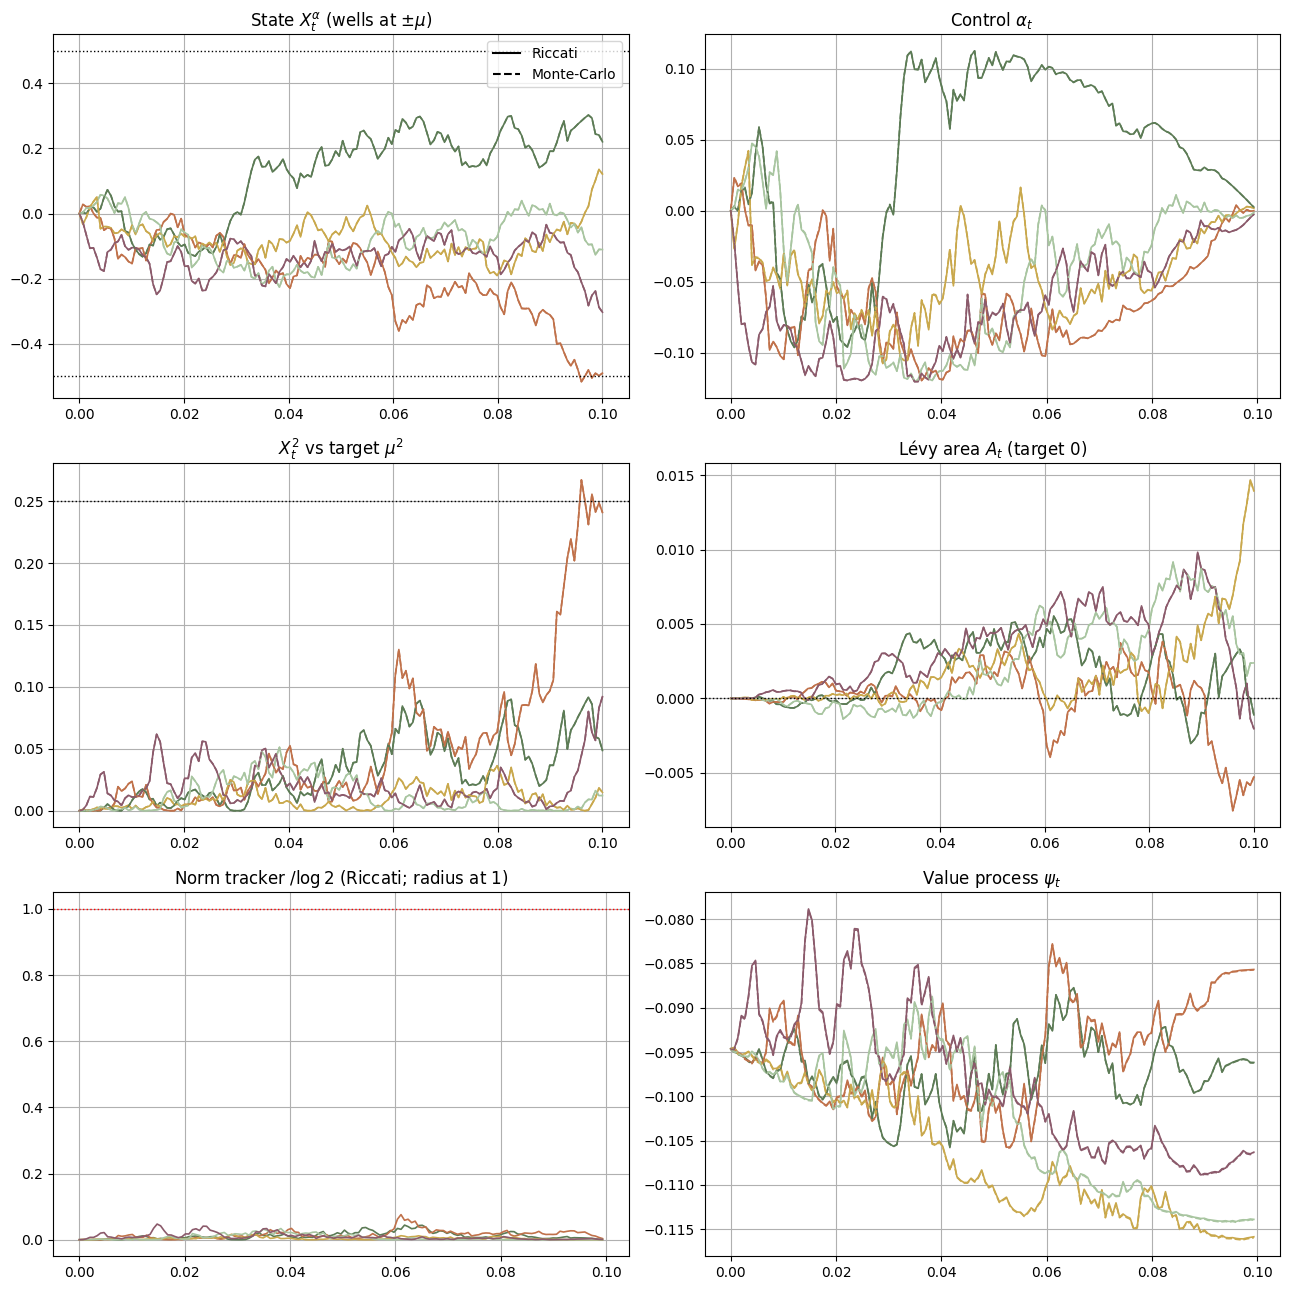

In [51]:
fig, ax = plt.subplots(3, 2, figsize=(13, 13))
styles = {"Riccati": "-", "Monte-Carlo": "--"}
for name, run in runs.items():
    A, ls = levy[name], styles[name]
    for k in range(size):
        col = PALETTE[k % len(PALETTE)]
        ax[0, 0].plot(t_grid, run.X[k], color=col, ls=ls, lw=1.2)
        ax[0, 1].plot(t_grid[:-1], run.control[k, :-1], color=col, ls=ls, lw=1.2)
        ax[1, 0].plot(t_grid, run.X[k] ** 2, color=col, ls=ls, lw=1.2)
        ax[1, 1].plot(t_grid, A[k], color=col, ls=ls, lw=1.2)
        ax[2, 1].plot(t_grid[:-1], run.value[k, :-1], color=col, ls=ls, lw=1.2)
        if "norm_tracker" in run.extra:
            ax[2, 0].plot(t_grid[:-1], run.extra["norm_tracker"][k, :-1], color=col, ls=ls, lw=1.2)
for s in (mu, -mu):
    ax[0, 0].axhline(s, color="k", ls=":", lw=1)
ax[1, 0].axhline(mu ** 2, color="k", ls=":", lw=1)
ax[1, 1].axhline(0.0, color="k", ls=":", lw=1)
ax[2, 0].axhline(1.0, color="r", ls=":", lw=1)
for lab, ls in styles.items():
    ax[0, 0].plot([], [], color="k", ls=ls, label=lab)
ax[0, 0].legend(loc="best")
ax[0, 0].set_title(r"State $X^\alpha_t$ (wells at $\pm\mu$)")
ax[0, 1].set_title(r"Control $\alpha_t$")
ax[1, 0].set_title(r"$X_t^2$ vs target $\mu^2$")
ax[1, 1].set_title(r"Lévy area $A_t$ (target $0$)")
ax[2, 0].set_title(r"Norm tracker $/\log 2$ (Riccati; radius at $1$)")
ax[2, 1].set_title(r"Value process $\psi_t$")
fig.tight_layout()

**One loop, two policies.** Both closed loops above come from the *same* `sig_control.simulate`, differing only in the policy passed in — `riccati_policy(psi)` (the local expansion) or `monte_carlo_policy(p, SigW1, …)` (the recentered Monte-Carlo expectation). State, signature trajectory, control and value all return in one `ControlResult`, and the Lévy area is read off the signature ($A_t=\tfrac12(\mathrm{Sig}^{12}-\mathrm{Sig}^{21})$). Where the norm tracker exceeds $1$ the Riccati expansion has left its radius of convergence and the two controls part ways — there the Monte-Carlo control (truncation-exact, since $p$ has finite degree) is the reliable one.

### Path-dependent running cost: tracking a moving target $Y_t$

A genuinely **time-dependent** cost: minimise $\int_0^T (X_t - Y_t)^2\,dt$ where $Y_t=\mu\sin(2\pi t/T)$ is the sinusoid from the signature-matching example. Writing $X_t=\langle\mathbf 2,\mathrm{Sig}(X)_t\rangle$, the running-cost coefficient is the **time-dependent source**
$$q_t \;=\; -w\big(\mathbf 2^{\,* 2} - 2Y_t\,\mathbf 2 + Y_t^2\,\varnothing\big),\qquad \langle q_t,\mathrm{Sig}(X)_t\rangle=-w\,(X_t-Y_t)^2,$$
with no terminal term ($r=0$). The Riccati solves this exactly through its time-dependent source; the Monte-Carlo uses `monte_carlo_source_policy`, which — by stationary increments $\mathrm{Sig}(W)_{t,s}\stackrel{d}{=}\mathrm{Sig}(W)_{0,s-t}$ — slices **one** precomputed Brownian-signature trajectory (no dilation) and applies the shift trick at each integration time $s$. We compare the two closed loops on the same Brownian paths.

In [52]:
# ===== Path-dependent running cost: track the moving target Y_t = mu sin(2 pi t / T) =====
from signature import sig_control as sc

w_track = 400.0                                    # weight on  int_0^T (X_t - Y_t)^2 dt
Y = lambda c: mu * np.sin(2 * np.pi * c / T_dw)   # sinusoidal target at calendar time c

# time-dependent source q_c = -w (X^2 - 2 Y(c) X + Y(c)^2)  =>  <q_c, Sig(X)_c> = -w (X_c - Y(c))^2.
# source[:, i] holds q at calendar time T - t_grid[i] (the solver's reversed-time order).
def q_track(c):
    return (ta.shuffle_pow(e_state, 2, shuffle_table) - e_state * (2.0 * Y(c)) + unit * (Y(c) ** 2)) * (-w_track)
source_track = ta.from_array(jnp.stack([q_track(T_dw - t_grid[i]).array for i in range(n_dw)], axis=1), trunc, dim)
r_track = ta.zero(trunc, dim)                     # purely running cost, no terminal term

# Riccati: solve the Riccati with the time-dependent source
psi_track = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=t_grid, init=r_track,
                            args={"shuffle_table": shuffle_table, "source": source_track})

# Monte-Carlo: precompute the Brownian-signature trajectory once (no dilation), then the policy
deg_track  = max(sc._max_degree(r_track), sc._max_degree(source_track))
traj_track = sc.brownian_signature_trajectory(t_grid, N_MC=100_000, trunc_mc=deg_track, dim=dim, seed=42)

policies_track = {"Riccati":     sc.riccati_policy(psi_track, source=source_track),
                  "Monte-Carlo": sc.monte_carlo_source_policy(r_track, source_track, traj_track, t_grid, dim)}
runs_track = {name: sc.simulate(dW_batch, t_grid, pol, trunc, dim) for name, pol in policies_track.items()}

print("deg(q) = %d  (Brownian signature truncated at %d => %d words)"
      % (deg_track, deg_track, int(ta.number_of_words_up_to_trunc(dim=dim, trunc=deg_track))))
print("max norm tracker (Riccati)     = %.2f  (local expansion valid while < 1)"
      % runs_track["Riccati"].extra["norm_tracker"][:, :-1].max())
print("max |alpha_Riccati - alpha_MC| = %.2e" %
      np.max(np.abs(runs_track["Riccati"].control[:, :-1] - runs_track["Monte-Carlo"].control[:, :-1])))
print("max |value_Riccati - value_MC| = %.2e" %
      np.max(np.abs(runs_track["Riccati"].value[:, :-1] - runs_track["Monte-Carlo"].value[:, :-1])))

deg(q) = 2  (Brownian signature truncated at 2 => 7 words)
max norm tracker (Riccati)     = 6.66  (local expansion valid while < 1)
max |alpha_Riccati - alpha_MC| = 1.27e-01
max |value_Riccati - value_MC| = 3.49e-02


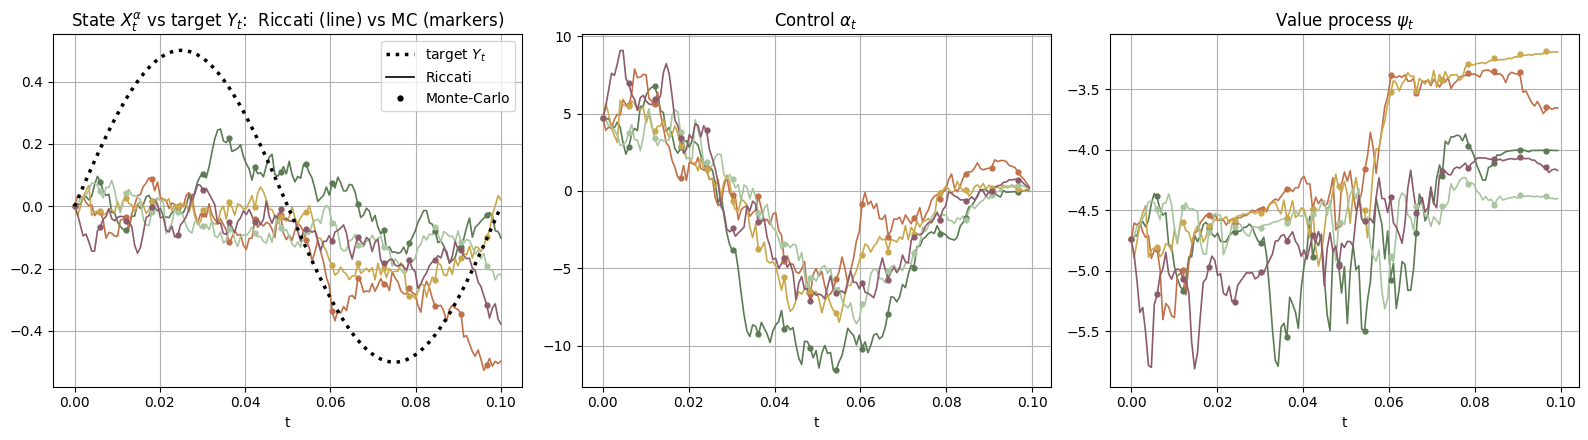

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
styles = {"Riccati": dict(ls="-", lw=1.2), "Monte-Carlo": dict(ls="none", marker="o", ms=3.5, markevery=9)}
for name, run in runs_track.items():
    for k in range(size):
        col = PALETTE[k % len(PALETTE)]
        ax[0].plot(t_grid, run.X[k], color=col, **styles[name])
        ax[1].plot(t_grid[:-1], run.control[k, :-1], color=col, **styles[name])
        ax[2].plot(t_grid[:-1], run.value[k, :-1], color=col, **styles[name])
ax[0].plot(t_grid, Y(t_grid), "k:", lw=2.5, label=r"target $Y_t$")
for lab in styles:
    ax[0].plot([], [], color="k", **styles[lab], label=lab)
ax[0].legend(loc="best")
ax[0].set_title(r"State $X^\alpha_t$ vs target $Y_t$:  Riccati (line) vs MC (markers)")
ax[1].set_title(r"Control $\alpha_t$")
ax[2].set_title(r"Value process $\psi_t$")
for a in ax:
    a.set_xlabel("t")
fig.tight_layout()

The Riccati and the path-dependent Monte-Carlo (`monte_carlo_source_policy`) closed loops coincide on the same Brownian paths (solid vs dashed overlap), confirming the new MC handles the time-dependent running cost correctly: it slices a single precomputed Brownian-signature trajectory instead of re-expanding anything, and applies the shift trick per integration time $s$. The state is biased toward the moving target $Y_t$; the norm tracker near $1$ marks the edge of the local expansion's radius — push $w$ higher and the Riccati *local* control leaves it while the Monte-Carlo stays exact.

### Double-well with moving wells $\pm Y_t$

The fixed double-well minima $\pm\mu$ of the first example are replaced by the **moving** target $Y_t=\mu\sin(2\pi t/T)$: running cost $\int_0^T (X_t^2 - Y_t^2)^2\,dt$, i.e. the time-dependent source
$$q_t=-w\,\big(\mathbf 2^{\,* 2}-Y_t^2\,\varnothing\big)^{* 2},\qquad \langle q_t,\mathrm{Sig}(X)_t\rangle=-w\,(X_t^2-Y_t^2)^2 .$$
The two wells sit at $X=\pm Y_t$ and oscillate (merging at $0$ when $Y_t=0$). As before the Riccati uses its time-dependent source and the Monte-Carlo `monte_carlo_source_policy` slices one Brownian-signature trajectory; we compare the two closed loops on the same Brownian paths.

In [56]:
# ===== Double-well with moving wells  X = +- Y_t   (running cost int (X^2 - Y_t^2)^2 dt) =====
w_dwell = 50.0
def q_dwell(c):                                          # q_c = -w (X^2 - Y(c)^2)^{shuffle 2}
    Z = ta.shuffle_pow(e_state, 2, shuffle_table) - unit * (Y(c) ** 2)    # X^2 - Y(c)^2
    return ta.shuffle_pow(Z, 2, shuffle_table) * (-w_dwell)
source_dwell = ta.from_array(jnp.stack([q_dwell(T_dw - t_grid[i]).array for i in range(n_dw)], axis=1), trunc, dim)
r_dwell = ta.zero(trunc, dim)                            # purely running cost

psi_dwell = ode_solver_traj(fun=ode_fun, step_fun=step_fun, t_grid=t_grid, init=r_dwell,
                            args={"shuffle_table": shuffle_table, "source": source_dwell})
deg_dwell  = max(sc._max_degree(r_dwell), sc._max_degree(source_dwell))
traj_dwell = sc.brownian_signature_trajectory(t_grid, N_MC=100_000, trunc_mc=deg_dwell, dim=dim, seed=3)

policies_dwell = {"Riccati":     sc.riccati_policy(psi_dwell, source=source_dwell),
                  "Monte-Carlo": sc.monte_carlo_source_policy(r_dwell, source_dwell, traj_dwell, t_grid, dim)}
runs_dwell = {name: sc.simulate(dW_batch, t_grid, pol, trunc, dim) for name, pol in policies_dwell.items()}

print("deg(q) = %d  (=> %d words) | norm tracker (Riccati) = %.2f"
      % (deg_dwell, int(ta.number_of_words_up_to_trunc(dim=dim, trunc=deg_dwell)),
         runs_dwell["Riccati"].extra["norm_tracker"][:, :-1].max()))
print("max |alpha_Riccati - alpha_MC| = %.2e" %
      np.max(np.abs(runs_dwell["Riccati"].control[:, :-1] - runs_dwell["Monte-Carlo"].control[:, :-1])))
print("max |value_Riccati - value_MC| = %.2e" %
      np.max(np.abs(runs_dwell["Riccati"].value[:, :-1] - runs_dwell["Monte-Carlo"].value[:, :-1])))

deg(q) = 4  (=> 31 words) | norm tracker (Riccati) = 0.11
max |alpha_Riccati - alpha_MC| = 4.33e-03
max |value_Riccati - value_MC| = 8.94e-04


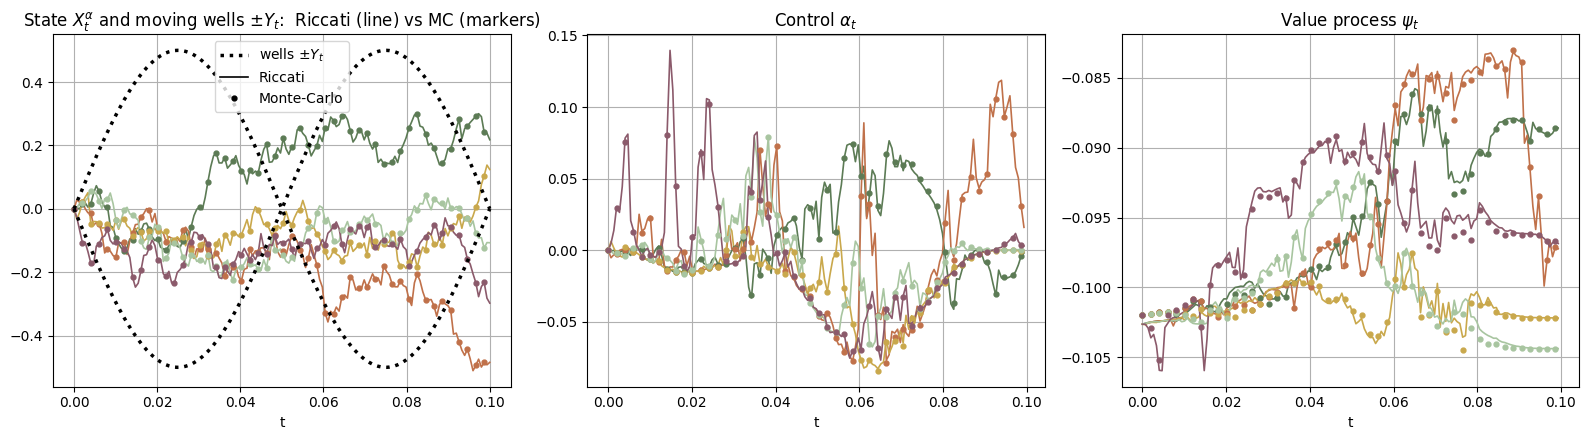

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
styles = {"Riccati": dict(ls="-", lw=1.2), "Monte-Carlo": dict(ls="none", marker="o", ms=3.5, markevery=3)}
for name, run in runs_dwell.items():
    for k in range(size):
        col = PALETTE[k % len(PALETTE)]
        ax[0].plot(t_grid, run.X[k], color=col, **styles[name])
        ax[1].plot(t_grid[:-1], run.control[k, :-1], color=col, **styles[name])
        ax[2].plot(t_grid[:-1], run.value[k, :-1], color=col, **styles[name])
ax[0].plot(t_grid, Y(t_grid), "k:", lw=2.5, label=r"wells $\pm Y_t$")
ax[0].plot(t_grid, -Y(t_grid), "k:", lw=2.5)
for lab in styles:
    ax[0].plot([], [], color="k", **styles[lab], label=lab)
ax[0].legend(loc="best")
ax[0].set_title(r"State $X^\alpha_t$ and moving wells $\pm Y_t$:  Riccati (line) vs MC (markers)")
ax[1].set_title(r"Control $\alpha_t$")
ax[2].set_title(r"Value process $\psi_t$")
for a in ax:
    a.set_xlabel("t")
fig.tight_layout()

The wells $\pm Y_t$ oscillate and merge at $0$; the controlled state stays near whichever moving well it fell into. Riccati (lines) and the path-dependent Monte-Carlo (markers) again agree on the same Brownian paths — markers sitting on the Riccati curves — confirming `monte_carlo_source_policy` on a second time-dependent cost.